In [46]:
vn30_2022 = ['CAP', 'EID', 'PHN', 'GVT', 'HVT', 'INN', 'DCM', 'HPG', 'GDW', 'DFC', 'TMG', 'PTB', 'PDN', 'CDN', 'NTP', 'TCW', 'THG', 'GDT', 'VCS', 'SDV', 'BWS', 'HMC', 'PNJ']



In [47]:
stocks = {
    "ngan_hang": ["VCB", "CTG", "BID", "MBB"],
    "nang_luong_vien_thong": ["GAS", "BSR", "PVD", "PVS", "VGI", "FOX", "CTR", "POW"],
    "ha_tang_logistic": ["ACV", "VTP"],
    "chung_khoan": ["SSI", "VND", "HCM", "VCI", "VPX", 'FTS'],
    "van_tai_bien": ["VOS", "GMD", "PHP", "VSC", "HAP", "VTP"],
    "tieu_dung": ["MWG", "PNJ", "DGW", "SAB", "MSN", "VNM"],
}

# Nếu bạn cần 1 list phẳng:
vn30_2022 = (
    stocks["ngan_hang"]
    + stocks["nang_luong_vien_thong"]
    + stocks["ha_tang_logistic"]
    + stocks["chung_khoan"]
    + stocks["van_tai_bien"]
    + stocks["tieu_dung"]
)


In [48]:
from vnstock import Vnstock
import pandas as pd
import numpy as np
from scipy import stats
import time


In [49]:
market_data =  Vnstock().stock(symbol='VNINDEX')
market_data = market_data.quote.history(start='2025-01-01', end='2026-02-28')
market_data['Return'] = market_data['close'].pct_change()
market_data

2026-03-04 22:30:56 - vnstock.common.data.data_explorer - INFO - Không phải là mã chứng khoán, thông tin công ty và tài chính không khả dụng.


,time,open,high,low,close,volume,Return
0,2025-01-02,1268.96,1271.13,1263.25,1269.71,328258670,NaN
1,2025-01-03,1268.74,1269.01,1254.59,1254.59,463010830,-0.011908
2,2025-01-06,1254.79,1260.37,1244.87,1246.35,469222998,-0.006568
3,2025-01-07,1249.19,1254.09,1243.06,1246.95,461894014,0.000481
4,2025-01-08,1246.16,1251.02,1239.67,1251.02,335193426,0.003264
...,...,...,...,...,...,...,...
279,2026-02-23,1833.90,1863.13,1833.90,1860.14,756872733,0.019763
280,2026-02-24,1862.18,1867.62,1849.60,1867.62,1002135553,0.004021
281,2026-02-25,1869.49,1876.01,1857.16,1860.91,1156532827,-0.003593
282,2026-02-26,1861.32,1882.17,1859.04,1879.64,891033680,0.010065


In [50]:
vnstock_api = Vnstock()
stock_data = vnstock_api.stock(symbol='CAP')
stock_data = stock_data.quote.history(start='2025-01-01', end='2026-02-28')
stock_data['time']

0     2025-01-02
1     2025-01-03
2     2025-01-06
3     2025-01-07
4     2025-01-08
         ...    
279   2026-02-23
280   2026-02-24
281   2026-02-25
282   2026-02-26
283   2026-02-27
Name: time, Length: 284, dtype: datetime64[ns]

In [51]:


# Initialize the Vnstock API instance
vnstock_api = Vnstock()

# Fetch market index data (VNINDEX)
market_data = vnstock_api.stock(symbol='VNINDEX')
market_data = market_data.quote.history(start='2025-01-01', end='2026-02-28')
market_data['Return'] = market_data['close'].pct_change()

# Initialize dictionary to store beta values
beta_values = {}

# Iterate through each stock in VN30
for symbol in vn30_2022:
    try:
        time.sleep(1)  # Sleep to avoid hitting API rate limits
        # Fetch historical stock data
        stock_data = vnstock_api.stock(symbol=symbol)
        stock_data = stock_data.quote.history(start='2025-01-01', end='2026-02-28')
        stock_data['Return'] = stock_data['close'].pct_change()

        # Merge stock returns with market returns
        merged_data = pd.merge(
            stock_data[['time', 'Return']],
            market_data[['time', 'Return']],
            on='time',
            suffixes=('_STOCK', '_VNINDEX')
        )
        merged_data.dropna(inplace=True)  # Remove rows with NaN values

        # Perform linear regression to calculate beta
        if not merged_data.empty:
            beta, alpha, r_value, p_value, std_err = stats.linregress(
                merged_data['Return_VNINDEX'], merged_data['Return_STOCK']
            )
            beta_values[symbol] = beta
        else:
            beta_values[symbol] = np.nan
    except Exception as e:
        print(f"Error processing stock {symbol}: {e}")
        beta_values[symbol] = np.nan

# Convert beta values to a DataFrame and display
beta_df = pd.DataFrame(list(beta_values.items()), columns=['Stock', 'Beta'])
print(beta_df)


2026-03-04 22:31:04 - vnstock.common.data.data_explorer - INFO - Không phải là mã chứng khoán, thông tin công ty và tài chính không khả dụng.


   Stock      Beta
0    VCB  0.834436
1    CTG  1.015367
2    BID  0.926695
3    MBB  0.996816
4    GAS  0.698790
5    BSR  1.139876
6    PVD  0.842797
7    PVS  0.987409
8    VGI  0.958697
9    FOX  0.846093
10   CTR  0.831606
11   POW  0.936297
12   ACV  0.673662
13   VTP  0.717974
14   SSI  1.258785
15   VND  1.343838
16   HCM  1.173571
17   VCI  1.154008
18   VPX  0.521458
19   FTS  1.112601
20   VOS  0.884649
21   GMD  0.966713
22   PHP  1.197269
23   VSC  1.387209
24   HAP  0.349719
25   MWG  1.111448
26   PNJ  0.894508
27   DGW  1.133152
28   SAB  0.565433
29   MSN  1.028768
30   VNM  0.644053


In [52]:
beta_values

{'VCB': 0.8344355063026112,
 'CTG': 1.0153670710183675,
 'BID': 0.9266945396092201,
 'MBB': 0.9968156132001715,
 'GAS': 0.6987896232582104,
 'BSR': 1.1398757732676346,
 'PVD': 0.8427967449060175,
 'PVS': 0.9874088059335459,
 'VGI': 0.9586972028725101,
 'FOX': 0.8460933746764391,
 'CTR': 0.8316063289434533,
 'POW': 0.9362973746686684,
 'ACV': 0.6736619253651944,
 'VTP': 0.7179742992979062,
 'SSI': 1.2587854791455466,
 'VND': 1.3438384462614006,
 'HCM': 1.1735707639635815,
 'VCI': 1.1540075386702884,
 'VPX': 0.5214579382791802,
 'FTS': 1.112601086503612,
 'VOS': 0.884649161204871,
 'GMD': 0.9667126399847344,
 'PHP': 1.1972689480013705,
 'VSC': 1.3872092073284006,
 'HAP': 0.34971886015240516,
 'MWG': 1.1114482251767916,
 'PNJ': 0.8945084158766266,
 'DGW': 1.1331524470654204,
 'SAB': 0.5654331490699412,
 'MSN': 1.0287680701454063,
 'VNM': 0.644053151701868}

In [53]:

# Define a function to calculate returns
def calculate_return(df):
    if df.empty:
        return 0
    first_price = df['close'].iloc[0]
    final_price = df['close'].iloc[-1] 
    stock_return = ((final_price - first_price)/first_price) * 100
    return stock_return

# Initialize dictionary to store stock returns
stock_return = {}

# Iterate through each stock in VN30
for stock in vn30_2022:
    try:
        # Fetch historical stock data
        stock_data = vnstock_api.stock(symbol=stock)
        stock_data = stock_data.quote.history(start='2025-01-01', end='2026-02-28')

        # Calculate the return rate
        return_rate = calculate_return(stock_data)
        stock_return[stock] = return_rate
    except Exception as e:
        print(f"Error processing stock {stock}: {e}")
        stock_return[stock] = np.nan

# Convert stock returns to a DataFrame and display
stock_return_df = pd.DataFrame(list(stock_return.items()), columns=['Stock', 'Return'])
print(stock_return_df)





   Stock      Return
0    VCB    6.341144
1    CTG   46.383467
2    BID   26.786660
3    MBB   73.252280
4    GAS   68.330733
5    BSR  121.906117
6    PVD   68.338421
7    PVS   50.047483
8    VGI   20.627262
9    FOX   30.775510
10   CTR  -22.197730
11   POW   46.169355
12   ACV  -30.707228
13   VTP  -24.713814
14   SSI   40.563991
15   VND   53.153153
16   HCM    8.939802
17   VCI   17.092457
18   VPX    3.896104
19   FTS  -14.120126
20   VOS   -5.982906
21   GMD   31.730919
22   PHP   -8.487435
23   VSC  108.534622
24   HAP   83.101852
25   MWG   55.841982
26   PNJ   28.572935
27   DGW   25.860374
28   SAB   -3.508772
29   MSN   11.581921
30   VNM   17.162000


In [54]:
stock_return

{'VCB': 6.341143699819768,
 'CTG': 46.38346727898967,
 'BID': 26.78665960825833,
 'MBB': 73.25227963525836,
 'GAS': 68.3307332293292,
 'BSR': 121.90611664295874,
 'PVD': 68.33842128216311,
 'PVS': 50.047483380816715,
 'VGI': 20.627261761158024,
 'FOX': 30.775510204081623,
 'CTR': -22.19773042697363,
 'POW': 46.16935483870968,
 'ACV': -30.70722828913157,
 'VTP': -24.713814172343554,
 'SSI': 40.5639913232104,
 'VND': 53.153153153153134,
 'HCM': 8.939802336028743,
 'VCI': 17.092457420924564,
 'VPX': 3.896103896103894,
 'FTS': -14.120126448893568,
 'VOS': -5.982905982905975,
 'GMD': 31.730919307007984,
 'PHP': -8.487434803224273,
 'VSC': 108.53462157809983,
 'HAP': 83.10185185185183,
 'MWG': 55.84198192166051,
 'PNJ': 28.572935344372958,
 'DGW': 25.860373647984275,
 'SAB': -3.5087719298245577,
 'MSN': 11.581920903954806,
 'VNM': 17.161999656416427}

In [55]:
# stock_return_series = pd.Series(stock_return)
# market_return = stock_return_series.mean()/100
# market_return
market_return = ((market_data['close'].iloc[-1] - market_data['close'].iloc[0])/market_data['close'].iloc[0])
market_return


0.48091296437769243

In [56]:
risk_free = [0.03317]
risk_free = pd.Series(risk_free)
R_f = risk_free.mean()
R_f

0.03317

In [57]:
df = pd.DataFrame(list(beta_values.items()), columns=['Stock', 'Beta'])

# Calculate the expected return using the CAPM formula
df['Expected Return'] = (R_f + df['Beta'] * (market_return - R_f)) * 100
df

,Stock,Beta,Expected Return
0,VCB,0.834436,40.678263
1,CTG,1.015367,48.779346
2,BID,0.926695,44.809096
3,MBB,0.996816,47.948718
4,GAS,0.698790,34.604814
5,BSR,1.139876,54.354136
6,PVD,0.842797,41.052631
7,PVS,0.987409,47.527535
8,VGI,0.958697,46.241993
9,FOX,0.846093,41.200236


In [58]:
top5_return = df.sort_values(by='Expected Return', ascending=False).head(5)
least_return = df.sort_values(by='Expected Return').head(5)
return_sorted = df.sort_values(by='Expected Return').reset_index(drop=True)
median_index = len(return_sorted) // 2
if len(return_sorted) % 2 == 0:
    median_stocks = return_sorted.iloc[median_index-2:median_index+3]
else:
    median_stocks = return_sorted.iloc[median_index-2:median_index+3]

near1_stock = df[(df['Beta'] < 1.1) & (df['Beta'] > 0.9)]
# print(median_stocks)
print(near1_stock)
# print(top5_return)
# print(least_return)

   Stock      Beta  Expected Return
1    CTG  1.015367        48.779346
2    BID  0.926695        44.809096
3    MBB  0.996816        47.948718
7    PVS  0.987409        47.527535
8    VGI  0.958697        46.241993
11   POW  0.936297        45.239056
21   GMD  0.966713        46.600878
29   MSN  1.028768        49.379367


In [59]:
top5_beta = df.sort_values(by='Beta', ascending=False).head(5)
least_beta = df.sort_values(by='Beta').head(5)
beta_sorted = df.sort_values(by='Beta').reset_index(drop=True)
median_index = len(beta_sorted) // 2
if len(beta_sorted) % 2 == 0:
    median_beta = beta_sorted.iloc[median_index-2:median_index+3]
else:
    median_beta = beta_sorted.iloc[median_index-2:median_index+3]

near1_stock = df[(df['Beta'] < 1.1) & (df['Beta'] > 0.9)]
# print(median_stocks)
print(near1_stock)

   Stock      Beta  Expected Return
1    CTG  1.015367        48.779346
2    BID  0.926695        44.809096
3    MBB  0.996816        47.948718
7    PVS  0.987409        47.527535
8    VGI  0.958697        46.241993
11   POW  0.936297        45.239056
21   GMD  0.966713        46.600878
29   MSN  1.028768        49.379367


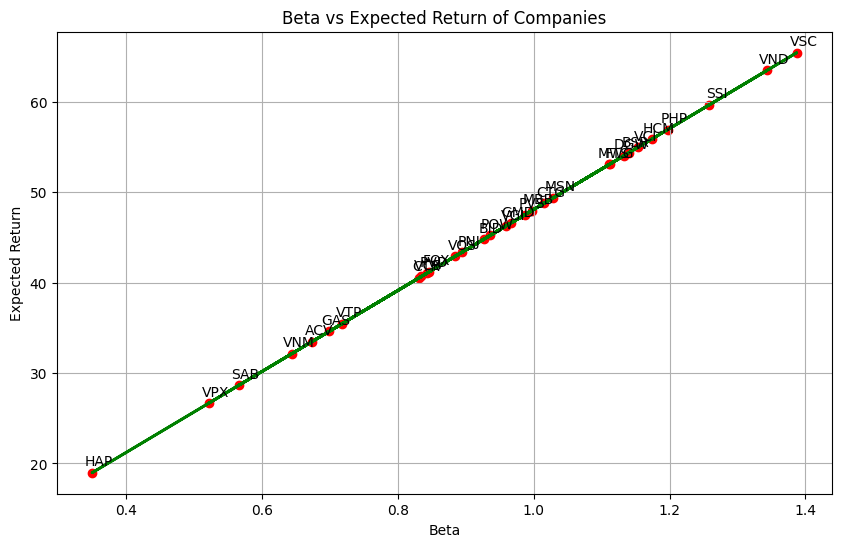

In [60]:
import matplotlib.pyplot as plt

# Plotting the chart with Beta on x-axis and Expected Return on y-axis
plt.figure(figsize=(10, 6))
plt.scatter(df['Beta'], df['Expected Return'], color='red')

# Line plot to connect all the points
plt.plot(df['Beta'], df['Expected Return'], color='green', linestyle='-', linewidth=2)

for i, txt in enumerate(df['Stock']):
    plt.annotate(txt, (df['Beta'][i], df['Expected Return'][i]), textcoords="offset points", xytext=(5,5), ha='center')

plt.title('Beta vs Expected Return of Companies')
plt.xlabel('Beta')
plt.ylabel('Expected Return')
plt.grid(True)
plt.show()

In [61]:
real_return = {}
for stock in vn30_2022:
    time.sleep(1)  # Sleep to avoid hitting API rate limits
    stock_data = Vnstock().stock(symbol=stock)
    stock_data = stock_data.quote.history(start='2025-01-01', end='2026-02-28')
    return_rate = calculate_return(stock_data)
    real_return[stock] = return_rate

In [62]:
real_stock_return = pd.Series(real_return)
real_stock_return = pd.DataFrame(real_stock_return, columns=['Return'])
real_stock_return

,Return
VCB,6.341144
CTG,46.383467
BID,26.786660
MBB,73.252280
GAS,68.330733
BSR,121.906117
PVD,68.338421
PVS,50.047483
VGI,20.627262
FOX,30.775510


In [63]:
real_stock_return.sort_values(by='Return', ascending=False).head(10)

,Return
BSR,121.906117
VSC,108.534622
HAP,83.101852
MBB,73.252280
PVD,68.338421
GAS,68.330733
MWG,55.841982
VND,53.153153
PVS,50.047483
CTG,46.383467


Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


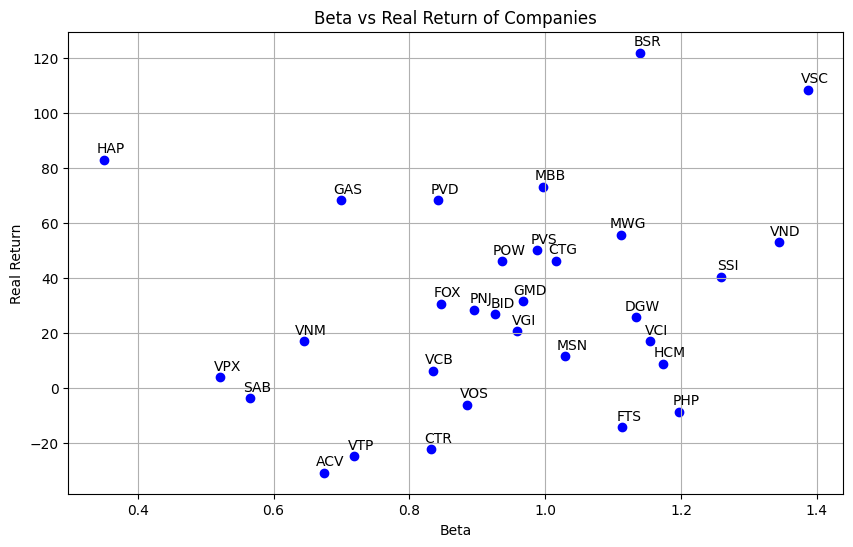

In [64]:
# Plotting the chart with Beta on x-axis and Expected Return on y-axis
plt.figure(figsize=(10, 6))
plt.scatter(df['Beta'], real_stock_return['Return'], color='blue')

for i, txt in enumerate(df['Stock']):
    plt.annotate(txt, (df['Beta'][i], real_stock_return['Return'][i]), textcoords="offset points", xytext=(5,5), ha='center')

plt.title('Beta vs Real Return of Companies')
plt.xlabel('Beta')
plt.ylabel('Real Return')
plt.grid(True)
plt.show()

In [65]:
real_stock_return['Return']

VCB      6.341144
CTG     46.383467
BID     26.786660
MBB     73.252280
GAS     68.330733
BSR    121.906117
PVD     68.338421
PVS     50.047483
VGI     20.627262
FOX     30.775510
CTR    -22.197730
POW     46.169355
ACV    -30.707228
VTP    -24.713814
SSI     40.563991
VND     53.153153
HCM      8.939802
VCI     17.092457
VPX      3.896104
FTS    -14.120126
VOS     -5.982906
GMD     31.730919
PHP     -8.487435
VSC    108.534622
HAP     83.101852
MWG     55.841982
PNJ     28.572935
DGW     25.860374
SAB     -3.508772
MSN     11.581921
VNM     17.162000
Name: Return, dtype: float64

In [66]:
real_stock_return

,Return
VCB,6.341144
CTG,46.383467
BID,26.786660
MBB,73.252280
GAS,68.330733
BSR,121.906117
PVD,68.338421
PVS,50.047483
VGI,20.627262
FOX,30.775510


In [67]:
new_df = df.set_index('Stock')[['Expected Return', 'Beta']]
new_df

,Expected Return,Beta
Stock,,
VCB,40.678263,0.834436
CTG,48.779346,1.015367
BID,44.809096,0.926695
MBB,47.948718,0.996816
GAS,34.604814,0.698790
BSR,54.354136,1.139876
PVD,41.052631,0.842797
PVS,47.527535,0.987409
VGI,46.241993,0.958697


In [68]:
concatenated_df = pd.concat([real_stock_return, new_df], axis=1)
concatenated_df

,Return,Expected Return,Beta
VCB,6.341144,40.678263,0.834436
CTG,46.383467,48.779346,1.015367
BID,26.786660,44.809096,0.926695
MBB,73.252280,47.948718,0.996816
GAS,68.330733,34.604814,0.698790
BSR,121.906117,54.354136,1.139876
PVD,68.338421,41.052631,0.842797
PVS,50.047483,47.527535,0.987409
VGI,20.627262,46.241993,0.958697
FOX,30.775510,41.200236,0.846093


In [69]:
concatenated_df['Deviation'] = concatenated_df['Return'] - concatenated_df['Expected Return']
variance_deviation = concatenated_df['Deviation'].var()
std_deviation = concatenated_df['Deviation'].std()
concatenated_df['beta_minus'] = 1 - concatenated_df['Beta']

In [70]:
print(variance_deviation)
print(std_deviation)

1319.3619228372788
36.32302193977366


In [71]:
# concatenated_df['beta_minus'] = 1 - concatenated_df['Beta']

In [72]:
concatenated_df.sort_values(by='beta_minus')

,Return,Expected Return,Beta,Deviation,beta_minus
VSC,108.534622,65.428316,1.387209,43.106305,-0.387209
VND,53.153153,63.486421,1.343838,-10.333268,-0.343838
SSI,40.563991,59.678234,1.258785,-19.114243,-0.258785
PHP,-8.487435,56.923875,1.197269,-65.411310,-0.197269
HCM,8.939802,55.862805,1.173571,-46.923003,-0.173571
VCI,17.092457,54.986876,1.154008,-37.894418,-0.154008
BSR,121.906117,54.354136,1.139876,67.551981,-0.139876
DGW,25.860374,54.053104,1.133152,-28.192730,-0.133152
FTS,-14.120126,53.132931,1.112601,-67.253057,-0.112601
MWG,55.841982,53.081312,1.111448,2.760670,-0.111448


Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


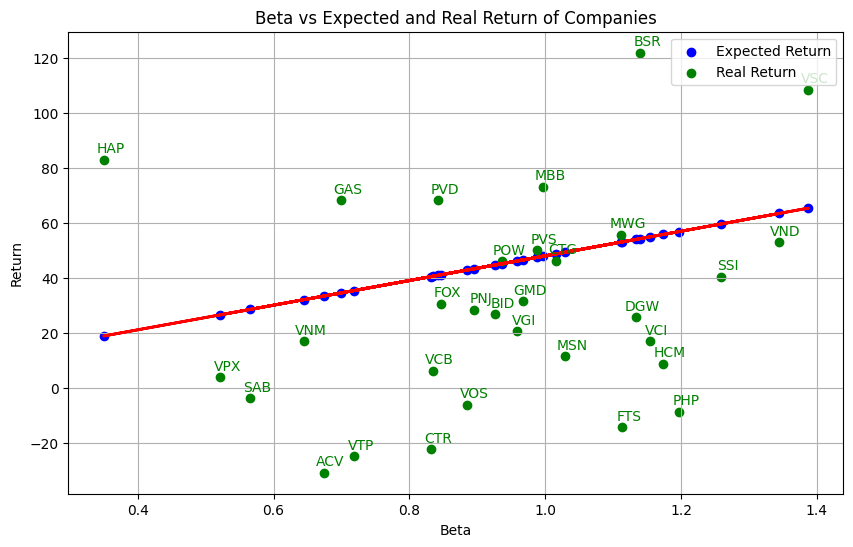

In [73]:
import matplotlib.pyplot as plt

# Assuming your DataFrame 'df' and 'real_stock_return' are already defined
plt.figure(figsize=(10, 6))

# Scatter plot for Expected Return
plt.scatter(df['Beta'], df['Expected Return'], color='blue', label='Expected Return')
plt.plot(df['Beta'], df['Expected Return'], color='red', linestyle='-', linewidth=2)

# Scatter plot for Real Return
plt.scatter(df['Beta'], real_stock_return['Return'], color='green', label='Real Return')

# Annotating each point with the corresponding stock name for Expected Return
# for i, txt in enumerate(df['Stock']):
#     plt.annotate(txt, (df['Beta'][i], df['Expected Return'][i]), textcoords="offset points", xytext=(5,5), ha='center', color='blue')

# Annotating each point with the corresponding stock name for Real Return
for i, txt in enumerate(df['Stock']):
    plt.annotate(txt, (df['Beta'][i], real_stock_return['Return'][i]), textcoords="offset points", xytext=(5,5), ha='center', color='green')

# Adding title and labels
plt.title('Beta vs Expected and Real Return of Companies')
plt.xlabel('Beta')
plt.ylabel('Return')
plt.grid(True)
plt.legend()  # Adding legend to differentiate between the two plots

# Show plot
plt.show()